# JIFLR Sensor Data Plotting Examples

This notebook demonstrates how to load the processed lvl0_main.nc file and create plots using matplotlib.

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from jiflr.data import select_sensors, unstack_sensor_idx

In [2]:
# Load and Explore the Dataset
ds = xr.open_dataset("../data/2025/processed/lvl1/lvl1_on_ice.nc")

# Explore the structure
print("Dataset overview:")
print(ds)
print("\nData variables:")
print(ds.data_vars)
print("\nCoordinates:")
print(ds.coords)

# Check data size
total_points = ds.temp_c.size
print(f"\nTotal data points: {total_points:,}")
print(f"Dataset memory usage: ~{total_points * 8 / 1024**2:.1f} MB")

Dataset overview:
<xarray.Dataset> Size: 16MB
Dimensions:            (datetime: 18089, sensor_idx: 55)
Coordinates:
  * datetime           (datetime) datetime64[ns] 145kB 2025-06-11T15:00:00 .....
  * sensor_idx         (sensor_idx) int64 440B 0 1 2 3 4 5 ... 49 50 51 52 53 54
    sensor_id          (sensor_idx) <U8 2kB ...
    site_id            (sensor_idx) <U4 880B ...
    height             (sensor_idx) <U2 440B ...
    shielding          (sensor_idx) <U10 2kB ...
    sensor_type        (sensor_idx) <U12 3kB ...
    sensor_generation  (sensor_idx) <U3 660B ...
    elevation          (sensor_idx) float64 440B ...
    latitude           (sensor_idx) float64 440B ...
    longitude          (sensor_idx) float64 440B ...
Data variables:
    temp_c             (datetime, sensor_idx) float64 8MB ...
    intensity_lux      (datetime, sensor_idx) float64 8MB ...
Attributes: (12/22)
    sensor_type:                  hobo pendant
    sensor_generation:            new
    sensor_id:           

In [10]:
ds.latitude.values

array([58.62173, 58.62173, 58.68347, 58.68347, 58.57856, 58.57856,
       58.65039, 58.65039, 58.81264, 58.81264, 58.69179, 58.69179,
       58.53802, 58.53802, 58.60366,      nan,      nan, 58.99744,
       58.99744, 58.99744, 58.66958, 58.66958, 58.5024 , 58.5024 ,
       58.62039, 58.62039,      nan, 58.6563 , 58.6563 , 58.83711,
       58.83711, 58.83711, 58.7693 , 58.7693 , 58.7693 , 58.57443,
       58.57443, 58.63437, 58.63437, 58.633  , 58.633  , 58.80668,
       58.80668, 58.64266, 58.64266, 58.62827, 58.62827, 58.82171,
       58.82171, 58.53996, 58.53996, 58.90988, 58.90988, 58.68831,
       58.68831])

## Plot 1: 2m Sensor Data for A02 and D04 Sites

In [4]:
# Select 2m sensor data for sites A02 and D04 using the new workflow
sites = ["D02", "D04"]

# Step 1: Select the sensors we want to analyze
selected_data = select_sensors(ds, site_id=sites, height="2m")

# Step 2: Unstack for convenient access
unstacked_data = unstack_sensor_idx(selected_data)

print(unstacked_data)

<xarray.Dataset> Size: 724kB
Dimensions:            (site_id: 2, datetime: 18089)
Coordinates:
  * site_id            (site_id) <U4 32B 'D02' 'D04'
  * datetime           (datetime) datetime64[ns] 145kB 2025-06-11T15:00:00 .....
    height             <U2 8B '2m'
    shielding          <U10 40B 'shielded'
    sensor_id          (site_id) <U8 64B '22133659' '22133630'
    sensor_type        (site_id) <U12 96B 'hobo pendant' 'hobo pendant'
    sensor_generation  (site_id) <U3 24B 'new' 'new'
    elevation          (site_id) float64 16B 1.406e+03 1.564e+03
    latitude           (site_id) float64 16B 58.68 58.64
    longitude          (site_id) float64 16B -134.4 -134.5
Data variables:
    temp_c             (datetime, site_id) float64 289kB nan nan nan ... nan nan
    intensity_lux      (datetime, site_id) float64 289kB nan nan nan ... nan nan
Attributes: (12/22)
    sensor_type:                  hobo pendant
    sensor_generation:            new
    sensor_id:                    2213364

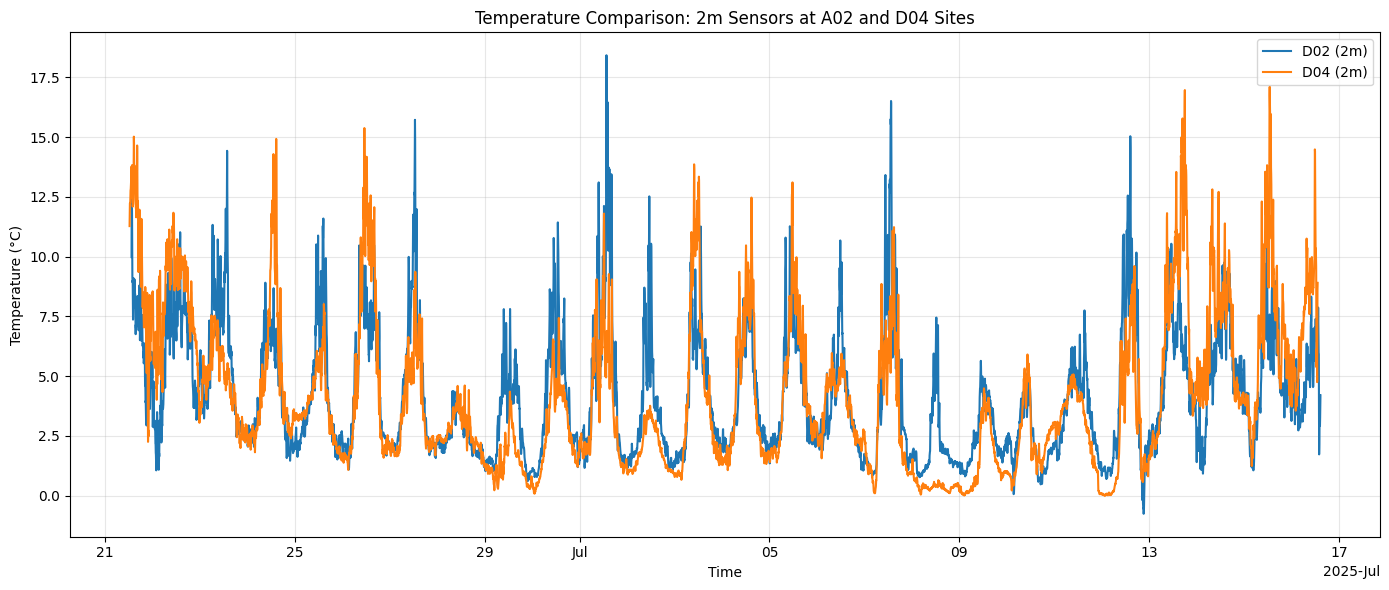

In [5]:
# Create the plot
fig, ax = plt.subplots(figsize=(14, 6))

# Step 3: Use familiar .sel() syntax to access data
for site in sites:
    temp_data = unstacked_data.temp_c.sel(site_id=site).dropna(dim="datetime")
    temp_data.plot(ax=ax, label=f"{site} (2m)", linewidth=1.5)

ax.set_title("Temperature Comparison: 2m Sensors at A02 and D04 Sites")
ax.set_xlabel("Time")
ax.set_ylabel("Temperature (°C)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Additional Analysis: Summary Statistics

In [6]:
# Calculate basic statistics using the select->unstack workflow
print("Temperature Statistics for Selected Sites and Heights:")
print("=" * 50)

# Use the already selected and unstacked data from above
for site in sites:
    print(f"\nSite {site}:")
    temp_data = unstacked_data.temp_c.sel(site_id=site)
    print(f"    Mean: {temp_data.mean().values:.2f}°C")
    print(f"    Min:  {temp_data.min().values:.2f}°C")
    print(f"    Max:  {temp_data.max().values:.2f}°C")
    print(f"    Std:  {temp_data.std().values:.2f}°C")

Temperature Statistics for Selected Sites and Heights:

Site D02:
    Mean: 4.18°C
    Min:  -0.76°C
    Max:  18.43°C
    Std:  2.60°C

Site D04:
    Mean: 4.13°C
    Min:  0.01°C
    Max:  17.11°C
    Std:  3.11°C


## Data Availability Check

In [7]:
# Check what sites and heights are actually available in the dataset
print("Available sites:", ds.site_id.values)
print("Available heights:", ds.height.values)
print("\nData availability matrix:")
print("Site\tHeight\tData Points")
print("-" * 30)

# For efficiency, select all data once and unstack
all_selected = select_sensors(ds)  # Select all sensors
all_unstacked = unstack_sensor_idx(all_selected)

for site in ds.site_id.values:
    for height in ds.height.values:
        try:
            temp_data = all_unstacked.temp_c.sel(
                site_id=site, height=height, shielding="shielded"
            )
            data_points = temp_data.count().values
            print(f"{site}\t{height}\t{data_points}")
        except KeyError:
            print(f"{site}\t{height}\t0")

Available sites: ['G01' 'G01' 'D02' 'D02' 'E03' 'E03' 'G04' 'G04' 'F05' 'F05' 'A05' 'A05'
 'B02' 'B02' 'A01' 'G03A' 'G03A' 'A10' 'A10' 'A10' 'A04' 'A04' 'B03' 'B03'
 'C02' 'C02' 'G03B' 'A03' 'A03' 'A07' 'A07' 'A07' 'A06' 'A06' 'A06' 'B01'
 'B01' 'A02' 'A02' 'E01' 'E01' 'F06' 'F06' 'D04' 'D04' 'G02' 'G02' 'F03'
 'F03' 'E04' 'E04' 'A08' 'A08' 'D01' 'D01']
Available heights: ['2m' '1m' '2m' '1m' '2m' '1m' '2m' '1m' '2m' '1m' '2m' '1m' '1m' '2m'
 '1m' '2m' '1m' '0m' '1m' '2m' '1m' '2m' '1m' '2m' '1m' '2m' '1m' '2m'
 '1m' '1m' '2m' '0m' '0m' '1m' '2m' '1m' '2m' '1m' '2m' '1m' '2m' '1m'
 '2m' '1m' '2m' '1m' '2m' '2m' '1m' '1m' '2m' '2m' '1m' '2m' '1m']

Data availability matrix:
Site	Height	Data Points
------------------------------
G01	2m	7470
G01	1m	7470
G01	2m	7470
G01	1m	7470
G01	2m	7470
G01	1m	7470
G01	2m	7470
G01	1m	7470
G01	2m	7470
G01	1m	7470
G01	2m	7470
G01	1m	7470
G01	1m	7470
G01	2m	7470
G01	1m	7470
G01	2m	7470
G01	1m	7470
G01	0m	0
G01	1m	7470
G01	2m	7470
G01	1m	7470
G01	2m	7470
G0

## Data Availability Timeline

Overlap period (ALL sites): 2025-06-23 to 2025-07-06 (14 days inclusive)
Overlap period (excluding B transect): 2025-06-23 to 2025-07-14 (22 days inclusive)


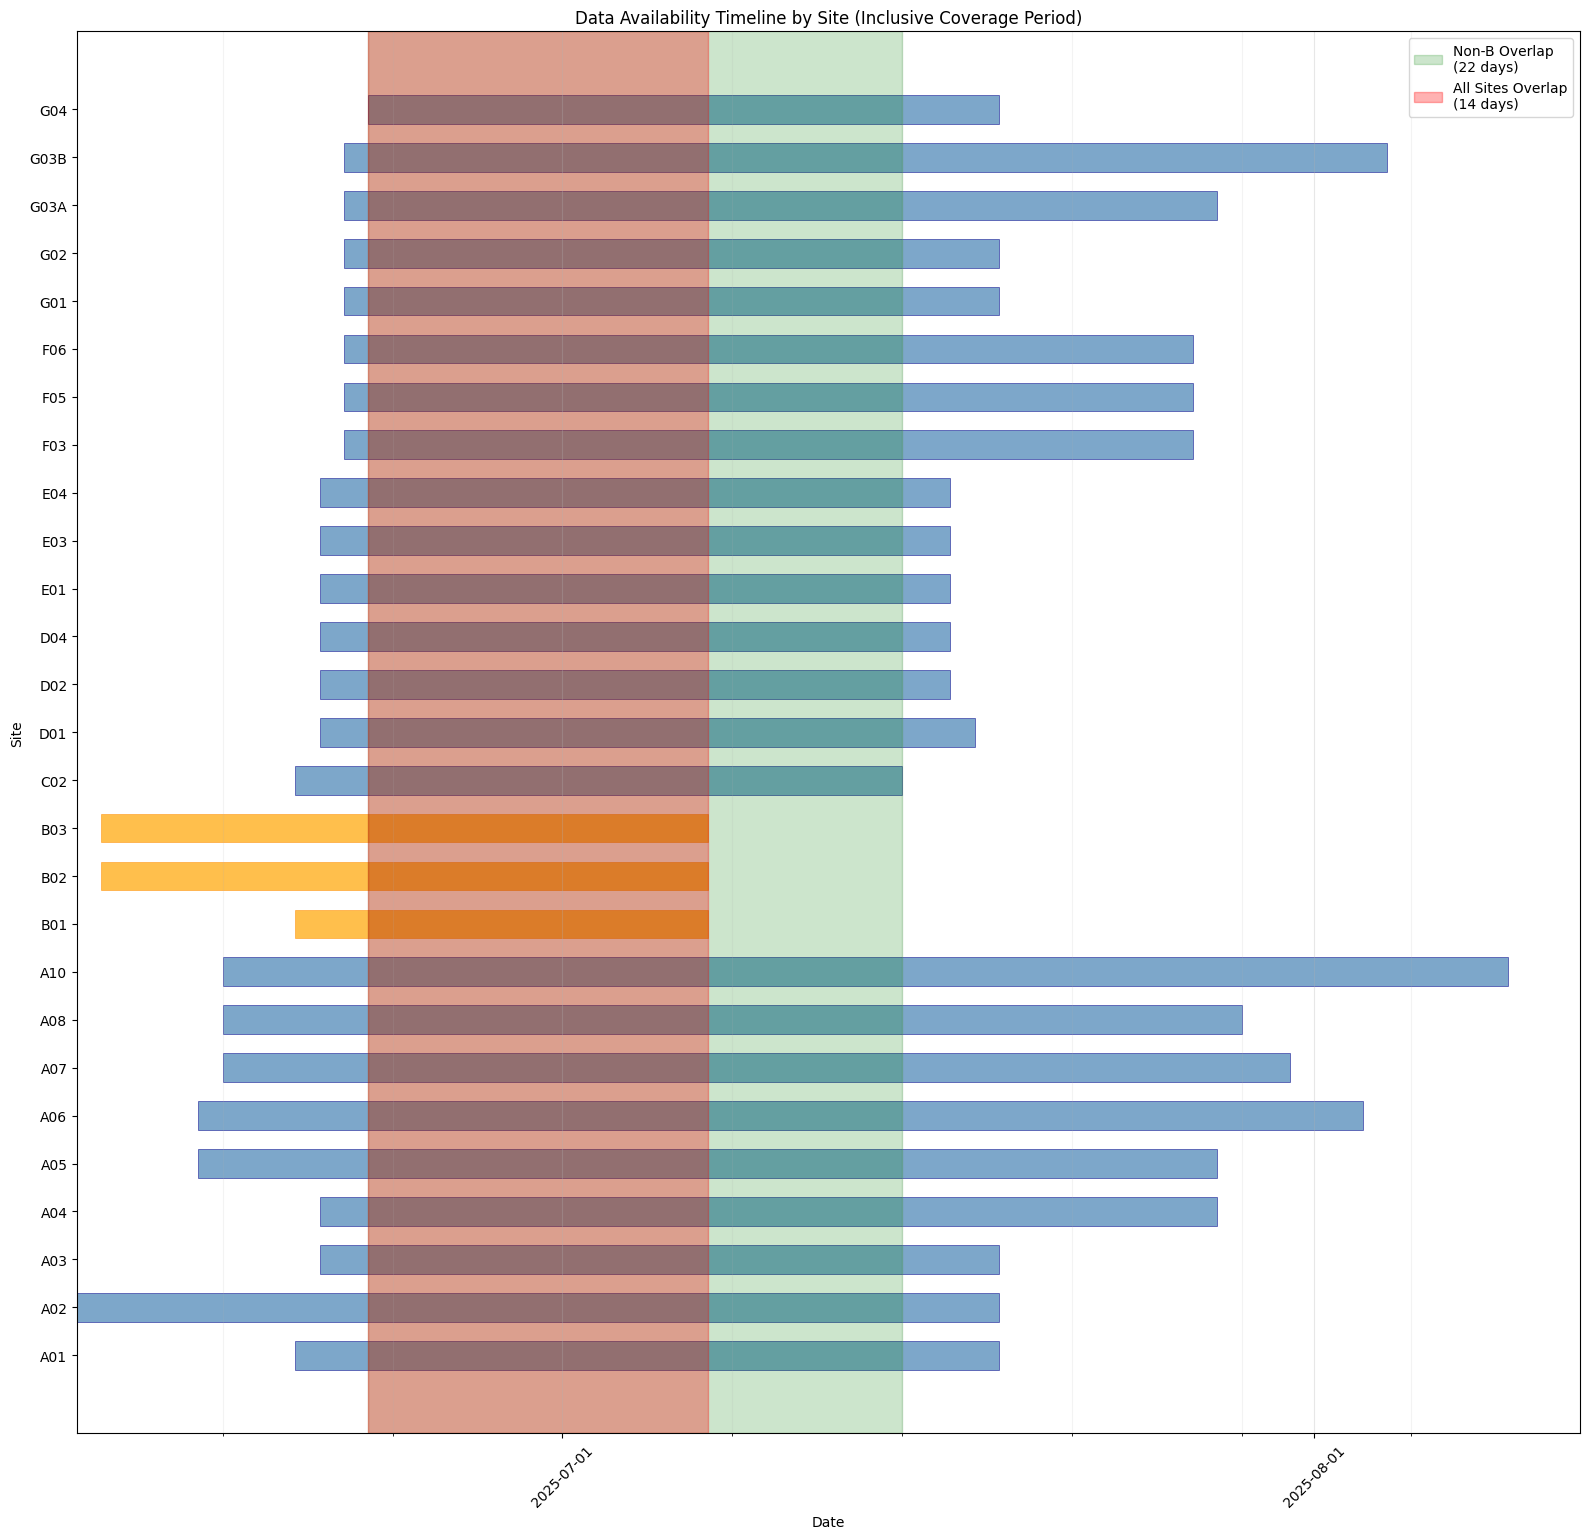


Data Availability Summary for 27 sites (inclusive):
A01 (Non-B): 2025-06-20 to 2025-07-18 (29 days)
A02 (Non-B): 2025-06-11 to 2025-07-18 (38 days)
A03 (Non-B): 2025-06-21 to 2025-07-18 (28 days)
A04 (Non-B): 2025-06-21 to 2025-07-27 (37 days)
A05 (Non-B): 2025-06-16 to 2025-07-27 (42 days)
A06 (Non-B): 2025-06-16 to 2025-08-02 (48 days)
A07 (Non-B): 2025-06-17 to 2025-07-30 (44 days)
A08 (Non-B): 2025-06-17 to 2025-07-28 (42 days)
A10 (Non-B): 2025-06-17 to 2025-08-08 (53 days)
B01 (B transect): 2025-06-20 to 2025-07-06 (17 days)
B02 (B transect): 2025-06-12 to 2025-07-06 (25 days)
B03 (B transect): 2025-06-12 to 2025-07-06 (25 days)
C02 (Non-B): 2025-06-20 to 2025-07-14 (25 days)
D01 (Non-B): 2025-06-21 to 2025-07-17 (27 days)
D02 (Non-B): 2025-06-21 to 2025-07-16 (26 days)
D04 (Non-B): 2025-06-21 to 2025-07-16 (26 days)
E01 (Non-B): 2025-06-21 to 2025-07-16 (26 days)
E03 (Non-B): 2025-06-21 to 2025-07-16 (26 days)
E04 (Non-B): 2025-06-21 to 2025-07-16 (26 days)
F03 (Non-B): 2025-06

In [8]:
# Create a simplified timeline plot showing data availability for each site
import matplotlib.dates as mdates
from datetime import datetime, timedelta

# Use the already unstacked data for efficiency
site_data = {}

for site in all_unstacked.site_id.values:
    site_spans = []
    for height in all_unstacked.height.values:
        try:
            temp_data = all_unstacked.temp_c.sel(
                site_id=site, height=height, shielding="shielded"
            )
            # Get non-null data points
            valid_data = temp_data.dropna(dim="datetime")

            if len(valid_data) > 0:
                start_date = pd.to_datetime(valid_data.datetime.min().values)
                end_date = pd.to_datetime(valid_data.datetime.max().values)
                site_spans.append((start_date, end_date))
        except KeyError:
            continue

    # Find the longest timespan for this site
    if site_spans:
        earliest_start = min(span[0] for span in site_spans)
        latest_end = max(span[1] for span in site_spans)

        # Make bars inclusive: extend to end of the last day
        earliest_start_inclusive = earliest_start.normalize()  # Start of the first day
        latest_end_inclusive = (
            latest_end.normalize() + timedelta(days=1) - timedelta(seconds=1)
        )  # End of the last day (11:59:59 PM)

        site_data[site] = (earliest_start_inclusive, latest_end_inclusive)

# Calculate overlap period for ALL sites
if site_data:
    overlap_start_all = max(start for start, end in site_data.values())
    overlap_end_all = min(end for start, end in site_data.values())

    # Only consider it an overlap if the period is positive
    if overlap_start_all <= overlap_end_all:
        overlap_period_all = (overlap_start_all, overlap_end_all)
        overlap_days_all = (
            overlap_end_all.normalize() - overlap_start_all.normalize()
        ).days + 1
        print(
            f"Overlap period (ALL sites): {overlap_start_all.strftime('%Y-%m-%d')} to {overlap_end_all.strftime('%Y-%m-%d')} ({overlap_days_all} days inclusive)"
        )
    else:
        overlap_period_all = None
        print("No overlap period found among all sites")
else:
    overlap_period_all = None

# Calculate overlap period EXCLUDING B transect sites
non_b_sites = {
    site: (start, end)
    for site, (start, end) in site_data.items()
    if not site.startswith("B")
}

if non_b_sites:
    overlap_start_no_b = max(start for start, end in non_b_sites.values())
    overlap_end_no_b = min(end for start, end in non_b_sites.values())

    if overlap_start_no_b <= overlap_end_no_b:
        overlap_period_no_b = (overlap_start_no_b, overlap_end_no_b)
        overlap_days_no_b = (
            overlap_end_no_b.normalize() - overlap_start_no_b.normalize()
        ).days + 1
        print(
            f"Overlap period (excluding B transect): {overlap_start_no_b.strftime('%Y-%m-%d')} to {overlap_end_no_b.strftime('%Y-%m-%d')} ({overlap_days_no_b} days inclusive)"
        )
    else:
        overlap_period_no_b = None
        print("No overlap period found among non-B transect sites")
else:
    overlap_period_no_b = None

# Create the timeline plot
fig, ax = plt.subplots(figsize=(16, len(site_data) * 0.5 + 2))

# Plot timeline bars for each site
sites = list(site_data.keys())
for i, (site, (start, end)) in enumerate(site_data.items()):
    # Calculate inclusive duration in days
    duration_days = (end.normalize() - start.normalize()).days + 1

    # Color code B transect sites differently
    color = "orange" if site.startswith("B") else "steelblue"

    # Plot thick horizontal bar showing data availability period
    ax.barh(
        i,
        duration_days,
        left=start,
        height=0.6,  # Thicker bars
        color=color,
        alpha=0.7,
        edgecolor="darkblue" if not site.startswith("B") else "darkorange",
        linewidth=0.5,
    )

# Add overlap period shading - first the non-B overlap (lighter), then all-sites overlap (darker)
if overlap_period_no_b:
    ax.axvspan(
        overlap_period_no_b[0],
        overlap_period_no_b[1],
        alpha=0.2,
        color="green",
        label=f"Non-B Overlap\n({overlap_days_no_b} days)",
    )

if overlap_period_all:
    ax.axvspan(
        overlap_period_all[0],
        overlap_period_all[1],
        alpha=0.3,
        color="red",
        label=f"All Sites Overlap\n({overlap_days_all} days)",
    )

# Customize the plot
ax.set_yticks(range(len(sites)))
ax.set_yticklabels(sites)
ax.set_xlabel("Date")
ax.set_ylabel("Site")
ax.set_title("Data Availability Timeline by Site (Inclusive Coverage Period)")

# Format x-axis dates with weekly gridlines
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_minor_locator(mdates.WeekdayLocator())  # Weekly gridlines

# Rotate x-axis labels
plt.xticks(rotation=45)

# Add grid - major monthly, minor weekly
ax.grid(True, alpha=0.3, axis="x", which="major")
ax.grid(True, alpha=0.15, axis="x", which="minor")

# Add legend
ax.legend(loc="upper right")

# Reduce spacing between y-axis items
plt.subplots_adjust(left=0.1, bottom=0.15, top=0.95)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nData Availability Summary for {len(site_data)} sites (inclusive):")
print("=" * 60)
b_sites = []
non_b_sites_list = []
for site, (start, end) in site_data.items():
    duration = (end.normalize() - start.normalize()).days + 1  # Inclusive count
    site_type = "B transect" if site.startswith("B") else "Non-B"
    print(
        f"{site} ({site_type}): {start.strftime('%Y-%m-%d')} to {end.strftime('%Y-%m-%d')} ({duration} days)"
    )

    if site.startswith("B"):
        b_sites.append(site)
    else:
        non_b_sites_list.append(site)

print(f"\nSite Categories:")
print(f"B transect sites ({len(b_sites)}): {', '.join(b_sites)}")
print(f"Non-B sites ({len(non_b_sites_list)}): {', '.join(non_b_sites_list)}")

if overlap_period_all:
    print(f"\nOverlap Analysis:")
    print(
        f"ALL sites overlap: {overlap_period_all[0].strftime('%Y-%m-%d')} to {overlap_period_all[1].strftime('%Y-%m-%d')} ({overlap_days_all} days)"
    )

if overlap_period_no_b:
    print(
        f"Non-B sites overlap: {overlap_period_no_b[0].strftime('%Y-%m-%d')} to {overlap_period_no_b[1].strftime('%Y-%m-%d')} ({overlap_days_no_b} days)"
    )

Demonstrating the select -> unstack -> analyze workflow:
Step 1: Selected 3 sensors
Step 2: Unstacked to dimensions: ['site_id', 'datetime']
Step 3: No data available for G01
Step 3: No data available for D02
Step 3: No data available for A05


/var/folders/bb/wssqxcxj4tgg0s9fdw74731m0000gn/T/ipykernel_7050/2114010429.py:12: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Step 2: Unstacked to dimensions: {list(unstacked_data.dims.keys())}")
/var/folders/bb/wssqxcxj4tgg0s9fdw74731m0000gn/T/ipykernel_7050/2114010429.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


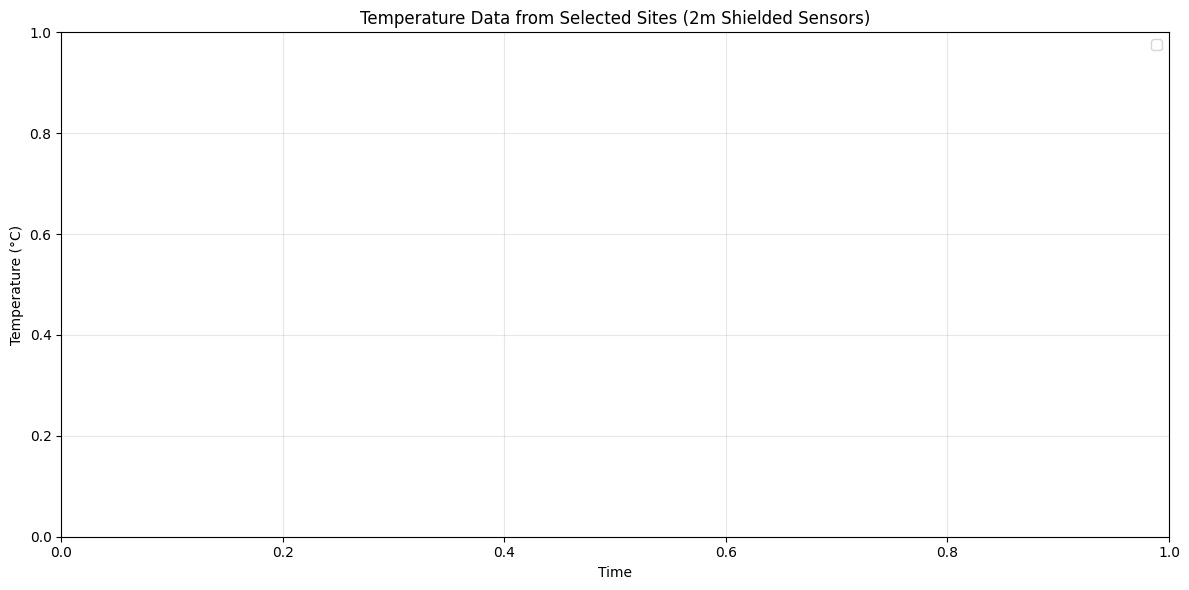


This workflow combines efficient filtering with intuitive data access!


In [9]:
# Example: Select a few sites, unstack, and create a simple plot
print("Demonstrating the select -> unstack -> analyze workflow:")

# Step 1: Select sensors we want to analyze
selected_data = select_sensors(
    ds, site_id=["G01", "D02", "A05"], height="2m", shielding="shielded"
)
print(f"Step 1: Selected {len(selected_data.sensor_idx)} sensors")

# Step 2: Unstack for convenient access
unstacked_data = unstack_sensor_idx(selected_data)
print(f"Step 2: Unstacked to dimensions: {list(unstacked_data.dims.keys())}")

# Step 3: Use familiar .sel() syntax and create a plot
fig, ax = plt.subplots(figsize=(12, 6))

for site in ["G01", "D02", "A05"]:
    try:
        temp_data = unstacked_data.temp_c.sel(
            site_id=site, height="2m", shielding="shielded"
        )
        temp_data.plot(ax=ax, label=site, linewidth=1.5, alpha=0.8)
        ax.plot(temp_data.datetime, temp_data.temp_c)
        print(f"Step 3: Plotted data for {site}")
    except KeyError:
        print(f"Step 3: No data available for {site}")

ax.set_title("Temperature Data from Selected Sites (2m Shielded Sensors)")
ax.set_xlabel("Time")
ax.set_ylabel("Temperature (°C)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nThis workflow combines efficient filtering with intuitive data access!")

## Using the New Convenience Functions

The JIFLR project provides two convenience functions designed to work together:

1. **`select_sensors()`** - Filter sensors by attributes (site_id, height, shielding, etc.)
2. **`unstack_sensor_idx()`** - Convert to traditional multi-dimensional structure

The recommended workflow is: **select → unstack → analyze**